# Nama Tim: BITin BYTE

## Import Libraries

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

try:
    import torch
    import transformers
    from torch.utils.data import Dataset, DataLoader
    from torch.optim import AdamW
    from transformers import (
        AutoTokenizer,
        AutoConfig,
        AutoModelForSequenceClassification,
        get_linear_schedule_with_warmup,
    )
    INDOBERT_AVAILABLE = True
    print('transformers tersedia:', transformers.__version__)
    print('PyTorch:', torch.__version__)
except Exception as e:
    INDOBERT_AVAILABLE = False
    print('IndoBERT tidak dapat dijalankan')
    print(type(e).__name__, str(e))

transformers tersedia: 5.16.1
PyTorch: 2.11.0+cu128


In [ ]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv('sample_submission.csv')

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
train.head()

,id,kalimat,sentiment
0,1,Breaking News: Wakil Ketua OJK Mirza Adityaswara Mundur,NETRAL
1,2,Simak Ini 4 Poin Penting Hasil RUPST Bank BRI,NETRAL
2,3,"119 BUMN Cetak Laba 64,2 Triliun, BRI Teratas",POSITIF
3,4,Bos BEI Beberkan Hasil Diskusi MSCI soal Reformasi Pasar Modal,NETRAL
4,5,8 Bulan Volume Transaksi AgenBRILink Tembus Rp 855 T,POSITIF


In [ ]:
train.tail()

,id,kalimat,sentiment
1521,1522,"Bos BGN Pastikan Anggaran MBG Tidak Dipangkas, Tetap Rp335 T",NEGATIF
1522,1523,"3 Nasabah BRI Juga Dibobol Rp 48,5 Juta Lewat ATM",NEGATIF
1523,1524,"Ini Pengusaha Muslim Terkaya di Dunia, Ada Pemilik Klub Sepak Bola",NEGATIF
1524,1525,"Metamorfosis Warung Kelontong Jakarta, Tak Lagi Jadul Berkat Ekosistem Digital BRI",POSITIF
1525,1526,"Multi Bintang (MLBI) Berencana Akusisi 99,9% Saham PT Karya Distilindo Sejahtera",NETRAL


In [ ]:
test.head()

,id,kalimat
0,1,Johan & Irwan Hidayat Borong Saham Sido Muncul (SIDO) hingga 3 Juta Lembar
1,2,"Meriah, 65 Ribu Peserta Keluarga Besar BRI Rayakan HUT yang Ke-124"
2,3,"Rupiah Menguat ke Rp 16.825 Per Dolar AS di Tengah Hari Ini (16/2), Yen Anjlok"
3,4,"Bank BRI di Pekanbaru Dirampok, Uang Rp97 Juta Digasak"
4,5,"Ingin Layani Pulau Terpencil, BRI Luncurkan Layanan Perbankan di Atas Kapal"


In [ ]:
test.tail()

,id,kalimat
649,650,Polrestabes Surabaya Dapat Bantuan Satu Unit Bus dari BRI
650,651,Bank BRI Tunjuk Aestika Oryza Gunarto Sebagai Corporate Secretary
651,652,Dirut BRI Beberkan Skenario Hadapi Ketidakpastian Ekonomi Global
652,653,BRI Jaga Kinerja Tetap Kinclong Lewat 6 Jurus Ini
653,654,BRI Salurkan Bantuan Obat-obatan hingga Tenda untuk Korban Gempa Sulbar


## Data Understanding & EDA (Exploratory Data Analysis)

### Data Dimension

In [ ]:
print("Train shape :", train.shape)
print("Test shape  :", test.shape)

Train shape : (1526, 3)
Test shape  : (654, 2)


### Column Names

In [ ]:
print("Train columns:")
print(train.columns.tolist())

print("\nTest columns:")
print(test.columns.tolist())

Train columns:
['id', 'kalimat', 'sentiment']

Test columns:
['id', 'kalimat']


Dataset terdiri dari 1.526 data train dengan 3 kolom (id, kalimat, sentiment) dan 654 data test dengan 2 kolom (id, kalimat). Pada data train, sentiment berperan sebagai target/label yang akan diprediksi oleh model berdasarkan informasi pada kolom kalimat. Sementara itu, data test tidak memiliki label sentiment karena digunakan untuk menghasilkan prediksi akhir. Kolom id berfungsi sebagai identitas data dan bukan sebagai fitur utama dalam klasifikasi.

### Check Data Types

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1526 entries, 0 to 1525
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         1526 non-null   int64 
 1   kalimat    1526 non-null   object
 2   sentiment  1526 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.9+ KB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       654 non-null    int64 
 1   kalimat  654 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.3+ KB


Seluruh kolom pada train dan test memiliki jumlah data yang lengkap dan tipe data yang sudah sesuai.

### Check Duplicate

In [ ]:
print("Full-row duplicate (train):", train.duplicated().sum())
print("Duplicate 'kalimat' (train):", train['kalimat'].duplicated().sum())

dup_mask = train['kalimat'].duplicated(keep=False)
print(f"\nTotal baris yang terlibat duplikasi: {dup_mask.sum()}")
train.loc[dup_mask, ['id', 'kalimat', 'sentiment']].sort_values('kalimat')

Full-row duplicate (train): 0
Duplicate 'kalimat' (train): 2

Total baris yang terlibat duplikasi: 4


,id,kalimat,sentiment
304,305,"5 Ciri Utama Golongan Warga Kelas Bawah, Ada di Kamu?",NEGATIF
538,539,"5 Ciri Utama Golongan Warga Kelas Bawah, Ada di Kamu?",NEGATIF
377,378,"Duit Warga RI Dimaling Rp 9,1 Triliun, Setiap Hari 1.000 Orang Teriak",POSITIF
634,635,"Duit Warga RI Dimaling Rp 9,1 Triliun, Setiap Hari 1.000 Orang Teriak",POSITIF


Terdapat 2 kalimat duplikat. Duplikasi kalimat di atas berlabel konsisten (kalimat yang sama memiliki sentiment yang sama). Ini artinya bukan noise/label error, hanya baris yang tercatat lebih dari sekali.

### Check ID Uniqueness

Karena dua row bisa mempunyai kalimat sama tetapi ID berbeda, maka kita perlu pemeriksaan id berikutnya / memastikan ID memang unik.

In [ ]:
print("Train ID unique:", train['id'].is_unique)
print("Test ID unique :", test['id'].is_unique)

print("\nTrain duplicate IDs:", train['id'].duplicated().sum())
print("Test duplicate IDs :", test['id'].duplicated().sum())

Train ID unique: True
Test ID unique : True

Train duplicate IDs: 0
Test duplicate IDs : 0


Tidak ada masalah dengan identifier.

### Check Missing Values

In [ ]:
print("Missing values in train:")
display(train.isnull().sum().to_frame(name='Missing Values'))

print("\nMissing values in test:")
display(test.isnull().sum().to_frame(name='Missing Values'))

Missing values in train:


,Missing Values
id,0
kalimat,0
sentiment,0



Missing values in test:


,Missing Values
id,0
kalimat,0


Tidak terdapat missing value baik di train maupun di test, tidak perlu melakukan imputation.

### Target Distribution

In [ ]:
sentiment_counts = train['sentiment'].value_counts()

print("Sentiment counts:")
print(sentiment_counts)

Sentiment counts:
sentiment
NETRAL     610
POSITIF    458
NEGATIF    458
Name: count, dtype: int64


In [ ]:
sentiment_percentage = (train['sentiment'].value_counts(normalize=True).mul(100).round(2))

print("Sentiment percentage:")
print(sentiment_percentage)

Sentiment percentage:
sentiment
NETRAL     39.97
POSITIF    30.01
NEGATIF    30.01
Name: proportion, dtype: float64


Data tidak terlalu imbalance.    
Netral memang lebih banyak, tapi masih bisa dianggap cukup balance.   
POSITIVE ≈ 30%, NEGATIVE ≈ 30%, NEUTRAL  ≈ 40%

### Check Target Label Consistency

In [ ]:
print("Unique sentiment labels:")
print(train['sentiment'].unique())

print("\nNumber of unique labels:")
print(train['sentiment'].nunique())

Unique sentiment labels:
['NETRAL' 'POSITIF' 'NEGATIF']

Number of unique labels:
3


In [ ]:
expected_labels = {'POSITIF', 'NETRAL', 'NEGATIF'}

actual_labels = set(train['sentiment'].dropna().unique())

print("Unexpected labels:")
print(actual_labels - expected_labels)

print("\nMissing expected labels:")
print(expected_labels - actual_labels)

Unexpected labels:
set()

Missing expected labels:
set()


Tidak ditemukan label yang tidak sesuai maupun label yang seharusnya ada tetapi tidak ditemukan. Dengan demikian, seluruh label target sudah konsisten dan sesuai dengan kategori yang ditentukan.

### Train-Test Sentences Overlap

In [ ]:
train_sentences = set(train['kalimat'])
test_sentences = set(test['kalimat'])

overlap_sentences = train_sentences.intersection(test_sentences)

print("Number of sentences appearing in both train and test:", len(overlap_sentences))

Number of sentences appearing in both train and test: 3


In [ ]:
overlap_df = train[train['kalimat'].isin(overlap_sentences)][['id', 'kalimat', 'sentiment']]
display(overlap_df)

,id,kalimat,sentiment
35,36,"Kejayaan Raja Ritel RI Runtuh, Jatuh ke Tangan Keluarga Riady",NEGATIF
377,378,"Duit Warga RI Dimaling Rp 9,1 Triliun, Setiap Hari 1.000 Orang Teriak",POSITIF
634,635,"Duit Warga RI Dimaling Rp 9,1 Triliun, Setiap Hari 1.000 Orang Teriak",POSITIF
1188,1189,"Anak Orang Penting Hidup Melarat, Ogah Jual Nama Ortu Untuk Sukses",POSITIF


Ada 3 kalimat test yang identik persis dengan kalimat di train (dan salah satunya muncul 2x di train dengan label yang sama). Karena kalimatnya identik kata-per-kata, secara teknis label train tersebut bisa dijadikan referensi untuk override prediksi pada 3 baris test tersebut.

### Text Characteristics

#### Text Length (Character Count & Word Count)

In [ ]:
train['char_count'] = train['kalimat'].str.len()
train['word_count'] = train['kalimat'].str.split().str.len()

print(train[['char_count', 'word_count']].describe())

        char_count   word_count
count  1526.000000  1526.000000
mean     62.976409     9.777195
std      11.730614     1.910497
min      24.000000     3.000000
25%      55.000000     8.000000
50%      63.000000    10.000000
75%      70.000000    11.000000
max     121.000000    16.000000


Panjang teks rata-rata sekitar 63 karakter atau 10 kata. Median yang hampir sama dengan rata-rata menunjukkan bahwa panjang kalimat secara umum berpusat di sekitar nilai tersebut.

Sebanyak 25% kalimat memiliki panjang maksimal 55 karakter atau 8 kata, sedangkan 75% kalimat memiliki panjang maksimal 70 karakter atau 11 kata. Kalimat terpendek terdiri dari 24 karakter dan 3 kata, sementara kalimat terpanjang terdiri dari 121 karakter dan 16 kata.

Secara umum, teks dalam dataset relatif pendek. Namun, terdapat variasi panjang kalimat, terutama pada character count, yang terlihat dari rentang 24–121 karakter. Informasi ini berguna untuk memahami bentuk data sebelum preprocessing dan pemodelan teks.

In [ ]:
length_summary = (train.groupby('sentiment')[['char_count', 'word_count']]
                  .agg(['mean', 'median', 'min', 'max'])
                  .round(2))
display(length_summary)

char_count                 word_count               
                mean median min  max       mean median min max
sentiment                                                     
NEGATIF        58.91   61.0  24  121       9.41    9.5   4  16
NETRAL         67.73   69.0  26   91      10.26   10.0   3  16
POSITIF        60.71   60.0  31  110       9.50    9.0   5  16

- NETRAL memiliki rata-rata teks paling panjang, yaitu sekitar 67,73 karakter atau 10,26 kata.   
- NEGATIF memiliki rata-rata teks paling pendek berdasarkan karakter, yaitu 58,91 karakter.   
- POSITIF berada di antara keduanya, dengan rata-rata 60,71 karakter.   
- Perbedaan rata-rata jumlah kata antarkelas relatif kecil, sekitar 9–10 kata per kalimat.

Dengan demikian, teks berlabel NETRAL cenderung lebih panjang dalam dataset ini. Namun, perbedaan panjang tersebut tidak membuktikan bahwa panjang kalimat menentukan sentimen. Panjang teks hanya salah satu karakteristik data yang diamati, bukan kesimpulan tentang hubungan sebab-akibat atau kemampuan klasifikasi.

Perlu diperhatikan juga bahwa nilai minimum dan maksimum menunjukkan adanya variasi panjang pada setiap kelas. Contohnya, kalimat terpanjang di kelas NEGATIF mencapai 121 karakter, lebih panjang daripada maksimum kelas NETRAL (91) dan POSITIF (110).

##### Word Count Ditribution

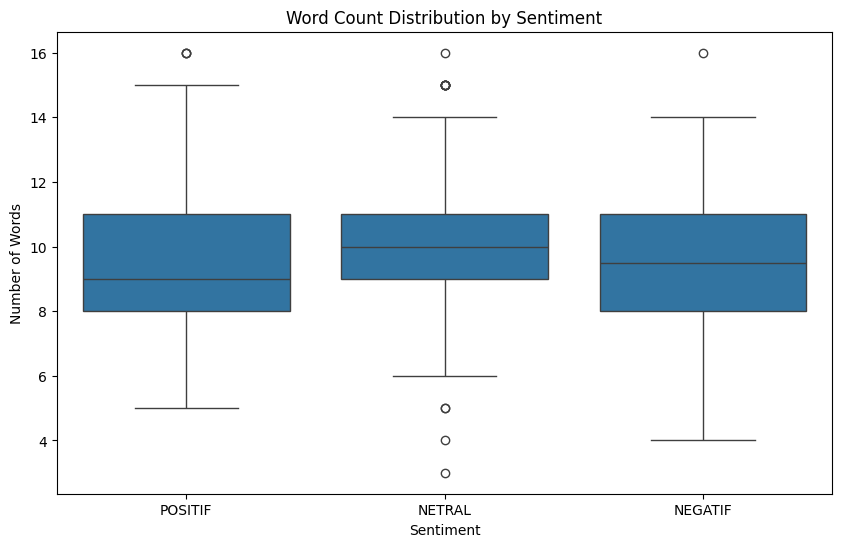

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='sentiment', y='word_count', order=['POSITIF', 'NETRAL', 'NEGATIF'])
plt.title('Word Count Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')
plt.show()

##### Character Count Distribution

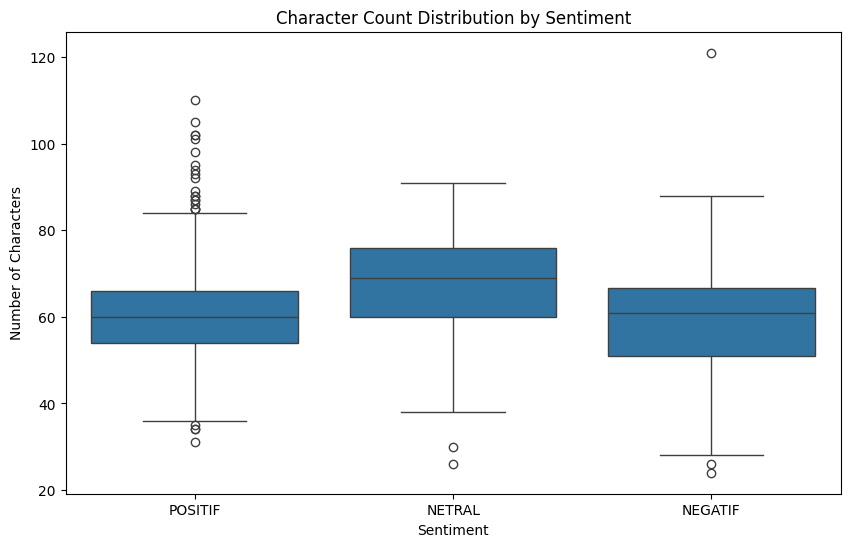

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=train, x='sentiment', y='char_count', order=['POSITIF', 'NETRAL', 'NEGATIF'])
plt.title('Character Count Distribution by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Number of Characters')
plt.show()

#### Check Uppercase/Lowercase

In [ ]:
train['uppercase_count'] = train['kalimat'].apply(
    lambda x: sum(1 for c in x if c.isupper()))
train['digit_count'] = train['kalimat'].apply(
    lambda x: sum(1 for c in x if c.isdigit()))
train['punctuation_count'] = train['kalimat'].apply(
    lambda x: sum(1 for c in x if not c.isalnum() and not c.isspace()))

display(train[['uppercase_count', 'digit_count', 'punctuation_count']].describe())

,uppercase_count,digit_count,punctuation_count
count,1526.000000,1526.000000,1526.000000
mean,11.595020,1.671691,1.325688
std,3.095817,2.317222,1.314018
min,5.000000,0.000000,0.000000
25%,10.000000,0.000000,0.000000
50%,11.000000,0.000000,1.000000
75%,13.000000,3.000000,2.000000
max,43.000000,15.000000,8.000000


- Rata-rata terdapat sekitar 11,6 huruf kapital per kalimat. Median 11 berarti separuh kalimat memiliki 11 atau lebih sedikit huruf kapital, dan separuh lainnya 11 atau lebih.

- Rata-rata terdapat sekitar 1,67 angka per kalimat, tetapi mediannya 0. Artinya, setidaknya separuh kalimat tidak mengandung angka; beberapa kalimat yang mengandung banyak angka menaikkan rata-ratanya.

- Rata-rata terdapat sekitar 1,33 karakter khusus per kalimat. Median 1 menunjukkan jumlah karakter khusus yang umum ditemukan berada di sekitar satu karakter per kalimat.

Nilai maksimum 43 huruf kapital, 15 angka, dan 8 karakter khusus menunjukkan ada kalimat dengan jumlah karakter tersebut cukup banyak. Nilai maksimum saja belum membuktikan bahwa teks itu salah atau perlu dihapus.

#### Check Sentences Containing Numbers

In [ ]:
numeric_text = train[train['kalimat']
                     .str.contains(r'\d', regex=True, na=False)]

print("Number of sentences containing digits:", len(numeric_text))
display(numeric_text[['id', 'kalimat', 'sentiment']].head(20))

Number of sentences containing digits: 734


,id,kalimat,sentiment
1,2,Simak Ini 4 Poin Penting Hasil RUPST Bank BRI,NETRAL
2,3,"119 BUMN Cetak Laba 64,2 Triliun, BRI Teratas",POSITIF
4,5,8 Bulan Volume Transaksi AgenBRILink Tembus Rp 855 T,POSITIF
5,6,"Prospek Emiten EBT Tergolong Cerah pada 2026, Ini Penyebabnya",NETRAL
8,9,"Ajak Satpam Bobol Brankas BRI Senilai Rp 1 Miliar, 1 Keluarga Diciduk",NEGATIF
9,10,"Rights Issue Beres, PANI Siap Genjot Bisnis di 2026",NETRAL
10,11,"Video: Buyback Saham, Ini Target Emiten Jasa Tambang DEWA di 2026",NEGATIF
12,13,"Intip Sederet Promo BRI Online Travel Fair 2022, Ada Diskon Flash Sale hingga 50 Persen",POSITIF
13,14,"Ini Alasan BRI Tebar Dividen Interim Rp 8,63 Triliun",NETRAL
14,15,"OJK Dalami 32 Kasus Pasar Modal, Targetkan Influencer Saham?",NETRAL


Terdapat 734 kalimat yang mengandung angka. Angka bisa menjadi bagian dari harga, persentase, tahun, atau ungakapan tertentu.

#### Check Special Characters

In [ ]:
special_char_pattern = r'[^a-zA-Z0-9\s]'

special_char_text = train[train['kalimat']
                          .str.contains(special_char_pattern, regex=True, na=False)]

print("Sentences containing special characters:", len(special_char_text))
display(special_char_text[['id', 'kalimat', 'sentiment']].head(20))

Sentences containing special characters: 1067


,id,kalimat,sentiment
0,1,Breaking News: Wakil Ketua OJK Mirza Adityaswara Mundur,NETRAL
2,3,"119 BUMN Cetak Laba 64,2 Triliun, BRI Teratas",POSITIF
5,6,"Prospek Emiten EBT Tergolong Cerah pada 2026, Ini Penyebabnya",NETRAL
6,7,Daftar Pejabat OJK yang Mengundurkan Diri usai Gonjang-ganjing Pasar Saham,NETRAL
7,8,"Transfer BRI Dinyatakan Sukses, Dana Tak Masuk Rekening Tujuan",NEGATIF
8,9,"Ajak Satpam Bobol Brankas BRI Senilai Rp 1 Miliar, 1 Keluarga Diciduk",NEGATIF
9,10,"Rights Issue Beres, PANI Siap Genjot Bisnis di 2026",NETRAL
10,11,"Video: Buyback Saham, Ini Target Emiten Jasa Tambang DEWA di 2026",NEGATIF
12,13,"Intip Sederet Promo BRI Online Travel Fair 2022, Ada Diskon Flash Sale hingga 50 Persen",POSITIF
13,14,"Ini Alasan BRI Tebar Dividen Interim Rp 8,63 Triliun",NETRAL


Terdapat 1067 kalimat yang mengandung special characters. Special characters yang muncul bisa memberi petunjuk tentang penekanan atau nada kalimat. Selain itu, pola ini hanya mengizinkan huruf Latin, jika teks mengandung huruf non-Latin atau karakter beraksen, karakter tersebut juga akan terdeteksi sebagai special characters.

#### Word & N-gram Frequency per Sentiment

##### Unigram

In [ ]:
def top_ngrams(texts, ngram_range=(1,1), top_n=15):
    vec = CountVectorizer(ngram_range=ngram_range, lowercase=True)
    X = vec.fit_transform(texts)
    freqs = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    order = np.argsort(freqs)[::-1][:top_n]
    return pd.DataFrame({'term': vocab[order], 'count': freqs[order]})

for label in ['POSITIF', 'NETRAL', 'NEGATIF']:
    subset = train.loc[train['sentiment'] == label, 'kalimat']
    print(f"Top Unigram - {label}")
    display(top_ngrams(subset, (1,1), top_n=10))

Top Unigram - POSITIF


,term,count
0,bri,388
1,di,93
2,rp,72
3,umkm,50
4,triliun,38
5,dan,35
6,2022,33
7,bank,33
8,ke,30
9,jadi,30


Top Unigram - NETRAL


,term,count
0,saham,175
1,ini,95
2,bri,93
3,ihsg,90
4,di,83
5,dan,78
6,2026,52
7,rekomendasi,52
8,ke,49
9,ojk,48


Top Unigram - NEGATIF


,term,count
0,bri,337
1,di,143
2,rp,76
3,nasabah,55
4,juta,47
5,atm,44
6,bank,40
7,ini,39
8,uang,38
9,polisi,37


Unigram -> masih didominasi entitas & stopword    
Seperti dugaan awal: bri, di, rp, dan, ke, ini muncul di ketiga kelas karena dataset memang berpusat pada berita BRI. Belum ada sinyal sentimen yang jelas di level kata tunggal, kecuali sedikit indikasi dari umkm/triliun (POSITIF), saham/ihsg/rekomendasi (NETRAL), dan nasabah/atm/polisi (NEGATIF). Ini konfirmasi bahwa unigram saja tidak cukup, sesuai catatan kamu sebelumnya.

##### Bigram

In [ ]:
for label in ['POSITIF', 'NETRAL', 'NEGATIF']:
    subset = train.loc[train['sentiment'] == label, 'kalimat']
    print(f"Top Bigram - {label}")
    display(top_ngrams(subset, (2,2), top_n=10))

Top Bigram - POSITIF


,term,count
0,bank bri,16
1,bri raih,13
2,bri salurkan,12
3,covid 19,11
4,tembus rp,10
5,umkm bri,10
6,rp triliun,10
7,dirut bri,10
8,salurkan bantuan,9
9,raih penghargaan,9


Top Bigram - NETRAL


,term,count
0,rekomendasi saham,22
1,rekomendasi sahamnya,16
2,wall street,15
3,pasar modal,15
4,simak rekomendasi,15
5,harga emas,14
6,di tengah,13
7,hari ini,12
8,net sell,12
9,ditutup menguat,12


Top Bigram - NEGATIF


,term,count
0,bri di,54
1,atm bri,37
2,bank bri,25
3,nasabah bri,23
4,uang nasabah,18
5,bri syariah,17
6,perampok bri,15
7,kredit bri,14
8,pegawai bri,13
9,kartu kredit,13


##### Trigram

In [ ]:
for label in ['POSITIF', 'NETRAL', 'NEGATIF']:
    subset = train.loc[train['sentiment'] == label, 'kalimat']
    print(f"Top Trigram - {label}")
    display(top_ngrams(subset, (3,3), top_n=10))

Top Trigram - POSITIF


,term,count
0,bri raih penghargaan,9
1,bri salurkan bantuan,8
2,laba bersih bri,6
3,umkm naik kelas,5
4,bri tembus rp,5
5,terdampak covid 19,4
6,cetak laba rp,4
7,naik kelas bri,4
8,bri danareksa sekuritas,4
9,salurkan bantuan ke,4


Top Trigram - NETRAL


,term,count
0,indeks bisnis 27,9
1,ihsg hari ini,8
2,sell terbesar asing,8
3,saham net sell,8
4,net sell terbesar,8
5,bisnis 27 ditutup,8
6,saham big banks,7
7,simak rekomendasi sahamnya,6
8,simak rekomendasi saham,6
9,ihsg ditutup menguat,6


Top Trigram - NEGATIF


,term,count
0,atm bri di,20
1,bank bri di,10
2,kartu kredit bri,9
3,di gedung bri,8
4,bri di medan,7
5,uang nasabah rp,6
6,uang nasabah bri,6
7,bri belum diterima,5
8,bri di bekasi,5
9,bri rs sardjito,5


Bigram & Trigram -> disini baru terlihat pola sentimen yang jelas.    

- POSITIF -> tema "pencapaian & pertumbuhan"
Frasa seperti bri raih penghargaan, laba bersih bri, cetak laba rp, kantongi laba rp, umkm naik kelas, bri salurkan bantuan menunjukkan pola konsisten: prestasi, laba, ekspansi bisnis, dan program CSR/pemberdayaan (bantuan ke UMKM). Ini benar-benar berbeda dari dua kelas lain — bahasa "meraih/mencetak/menyalurkan" jadi penanda kuat.

- NETRAL -> tema "laporan pasar/informasi faktual"
rekomendasi saham, ihsg hari ini, net sell terbesar asing, harga emas, ditutup menguat, indeks bisnis 27 — ini bahasa laporan pasar rutin/objektif (rekap penutupan bursa, data indeks, rekomendasi analis). Menariknya, kata "menguat" justru muncul di NETRAL, bukan POSITIF — artinya kenaikan indeks yang dilaporkan sebagai fakta pasar harian dianggap netral, beda dengan pencapaian spesifik BRI yang dianggap positif. Ini insight penting: kata yang sama bisa berarti beda tergantung konteks/framing kalimatnya, jadi model perlu menangkap kombinasi kata (n-gram/konteks), bukan cuma keyword tunggal.

- NEGATIF -> tema "insiden/kejahatan & keluhan nasabah"
perampok bri, atm bri di [lokasi], uang nasabah rp, kartu kredit bri, bri belum diterima — pola yang sangat konsisten: perampokan/pembobolan, dana nasabah bermasalah, keluhan layanan (belum diterima). Kemunculan nama lokasi (bri di medan, bri di bekasi) juga khas berita insiden/kejadian spesifik, bukan laporan umum.

### Shortest and Longest Sentence

In [ ]:
print("Kalimat terpendek:")
display(train.nsmallest(5, 'word_count')[['kalimat', 'sentiment', 'word_count']])

print("\nKalimat terpanjang:")
display(train.nlargest(5, 'word_count')[['kalimat', 'sentiment', 'word_count']])

Kalimat terpendek:


,kalimat,sentiment,word_count
1488,Pascapeluncuran Satelit BRIsat,NETRAL,3
420,"BRI Offline, Nasabah Repot",NEGATIF,4
584,Ini Status Teranyar BRIsat,NETRAL,4
110,"BRIsat, Momentum Kebangkitan Satelit Indonesia",POSITIF,5
188,Dari Tempat Inilah BRIsat Dikendalikan,NETRAL,5



Kalimat terpanjang:


,kalimat,sentiment,word_count
19,"Lewat BRIMO Future Garuda, BRI Dorong Talenta Muda Timba Ilmu Dari 4 Legenda Sepak Bola Dunia",POSITIF,16
200,"Dicuekin, Dicurigai hingga Diancam Dilaporkan, Pionir Agen BRILink di Brebes Ini Pantang Menyerah Demi Meyakinkan Nasabah",NEGATIF,16
388,"Lagi, BRI Raih 2 Penghargaan Internasional untuk Inovasi Layanan Nasabah di Ajang Asia Trailblazer Awards 2023",POSITIF,16
709,"Ikut Fit and Proper Test OJK, Hasan Fawzi Targetkan Market Cap Pasar RI Capai 80% PDB",NETRAL,16
763,BRI Antarkan UMKM Indonesia ke New York (NY) NOW 2023 Komitmen Dukung Alumni UMKM EXPO(RT) BRILIANPRENEUR,POSITIF,16


Panjang kalimat dalam dataset berkisar antara 3–16 kata. Kalimat terpendek umumnya berupa headline singkat yang tetap memiliki konteks sentimen, seperti “BRI Offline, Nasabah Repot” pada kelas NEGATIF. Sementara itu, kalimat terpanjang cenderung memberikan konteks yang lebih lengkap, seperti informasi mengenai penghargaan, program, atau kondisi pasar. Dari sampel tiap sentimen, terlihat bahwa POSITIF banyak menonjolkan pencapaian dan pertumbuhan, NETRAL berisi informasi atau kondisi pasar, sedangkan NEGATIF lebih sering berkaitan dengan masalah, kehilangan dana, dan kasus kriminal. Hal ini menunjukkan bahwa meskipun kalimat relatif pendek, konteks headline tetap memberikan pola yang cukup jelas untuk membedakan sentimen."

### Sample Text per Sentiment

In [ ]:
RANDOM_STATE = 42
for label in ['POSITIF', 'NETRAL', 'NEGATIF']:
    print(f"\n{label}")
    display(train.loc[train['sentiment'] == label, ['kalimat']].sample(5, random_state=RANDOM_STATE))


POSITIF


,kalimat
987,Optimis Hadapi 2023 Dengan Layanan Keuangan BRI Prioritas
110,"BRIsat, Momentum Kebangkitan Satelit Indonesia"
1126,Dirut BRI Sunarso Dinobatkan Sebagai Tokoh Finansial Indonesia 2020
697,"Tabungan Orang Kaya Tumbuh Tinggi, Kelas Menengah Seret"
480,FWD Group Suntik Modal ke BRI Life



NETRAL


,kalimat
220,Bos LPS: Bank Syariah Kini Lebih Menarik dari Konvensional
569,"Korban Warga Bogor, Sedang Ikut Pelatihan BRI"
148,"Transaksi Saham BUMI Tembus Rp 1,73 Triliun, Sahamnya Justru Anjlok"
1492,"Simak Saham yang Banyak Diborong Asing Saat IHSG Ambles 3,05%, Jumat (13/3)"
672,"Progres Capai 62%, WIKA Kebut Proyek Jalan Hankam & Lingkar Sepaku"



NEGATIF


,kalimat
1047,ATM BRI di Indomart Menteng Dibobol Maling
137,Teler BRI Penilep Dana PIP Sudah Diberhentikan
1156,Polisi Selidiki Soal Uang Nasabah BRI Rp 87 Juta Lenyap di Rekening
772,"Terdakwa Sakit, Sidang Vonis Eks Pimpinan BRI Kembali Ditunda"
499,"Kisah Stanley Druckenmiller, Investor Kaya Penakluk Bank of England"


Sampel menunjukkan pola konteks yang cukup jelas pada setiap kelas. POSITIF cenderung berisi pencapaian, pertumbuhan, dan perkembangan seperti “dinobatkan”, “kebangkitan”, dan “suntik modal”. NETRAL lebih banyak menyampaikan informasi atau kondisi pasar tanpa sentimen yang dominan, seperti transaksi saham dan perkembangan proyek. Sementara itu, NEGATIF banyak berkaitan dengan masalah, kehilangan dana, kriminalitas, dan kasus hukum. Hal ini menunjukkan bahwa konteks dalam headline dapat menjadi indikator penting untuk membedakan sentimen.

## Data Preparation

Berdasarkan Text EDA di atas, kalimatnya pendek dan makna bisa berubah drastis akibat penghilangan
kata (negasi, frasa 2-3 kata). Karena itu baseline pertama **tidak** melakukan stopword removal,
stemming, atau penghapusan angka/karakter khusus, cukup lowercasing yang otomatis dilakukan
`TfidfVectorizer`.

In [ ]:
train_prep = train[['id', 'kalimat', 'sentiment']].copy()
test_prep = test[['id', 'kalimat']].copy()

print("Train preparation shape:", train_prep.shape)
print("Test preparation shape :", test_prep.shape)

Train preparation shape: (1526, 3)
Test preparation shape : (654, 2)


### Standardizing Text Format

In [ ]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train_prep['kalimat_clean'] = train_prep['kalimat'].apply(clean_text)
test_prep['kalimat_clean'] = test_prep['kalimat'].apply(clean_text)
display(train_prep[['kalimat', 'kalimat_clean']].head(10))

,kalimat,kalimat_clean
0,Breaking News: Wakil Ketua OJK Mirza Adityaswara Mundur,breaking news: wakil ketua ojk mirza adityaswara mundur
1,Simak Ini 4 Poin Penting Hasil RUPST Bank BRI,simak ini 4 poin penting hasil rupst bank bri
2,"119 BUMN Cetak Laba 64,2 Triliun, BRI Teratas","119 bumn cetak laba 64,2 triliun, bri teratas"
3,Bos BEI Beberkan Hasil Diskusi MSCI soal Reformasi Pasar Modal,bos bei beberkan hasil diskusi msci soal reformasi pasar modal
4,8 Bulan Volume Transaksi AgenBRILink Tembus Rp 855 T,8 bulan volume transaksi agenbrilink tembus rp 855 t
5,"Prospek Emiten EBT Tergolong Cerah pada 2026, Ini Penyebabnya","prospek emiten ebt tergolong cerah pada 2026, ini penyebabnya"
6,Daftar Pejabat OJK yang Mengundurkan Diri usai Gonjang-ganjing Pasar Saham,daftar pejabat ojk yang mengundurkan diri usai gonjang-ganjing pasar saham
7,"Transfer BRI Dinyatakan Sukses, Dana Tak Masuk Rekening Tujuan","transfer bri dinyatakan sukses, dana tak masuk rekening tujuan"
8,"Ajak Satpam Bobol Brankas BRI Senilai Rp 1 Miliar, 1 Keluarga Diciduk","ajak satpam bobol brankas bri senilai rp 1 miliar, 1 keluarga diciduk"
9,"Rights Issue Beres, PANI Siap Genjot Bisnis di 2026","rights issue beres, pani siap genjot bisnis di 2026"


In [ ]:
print("Empty cleaned text in train:", (train_prep['kalimat_clean'] == '').sum())
print("Empty cleaned text in test:", (test_prep['kalimat_clean'] == '').sum())

Empty cleaned text in train: 0
Empty cleaned text in test: 0


Teks dibersihkan dengan mengubah seluruh huruf menjadi lowercase dan merapikan spasi berlebih tanpa menghilangkan informasi penting pada kalimat. Hasil pemeriksaan menunjukkan tidak terdapat teks kosong baik pada train maupun test, sehingga seluruh data dapat digunakan untuk tahap pemodelan.

### Drop Duplicate Sentence

Sebelum split, drop duplikat kalimat supaya tidak ada baris identik yang jatuh di train dan validation set sekaligus.

In [ ]:
train_dedup = train.drop_duplicates(subset='kalimat').reset_index(drop=True)
print("Sebelum drop duplicate:", train.shape[0], "-> Sesudah:", train_dedup.shape[0])

Sebelum drop duplicate: 1526 -> Sesudah: 1524


### Train-Validation Split

In [ ]:
X = train_dedup['kalimat']
y = train_dedup['sentiment']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape[0], "| Valid:", X_valid.shape[0])
print(y_train.value_counts(normalize=True).round(3))
print(y_valid.value_counts(normalize=True).round(3))

Train: 1219 | Valid: 305
sentiment
NETRAL     0.400
POSITIF    0.300
NEGATIF    0.299
Name: proportion, dtype: float64
sentiment
NETRAL     0.400
NEGATIF    0.302
POSITIF    0.298
Name: proportion, dtype: float64


Dataset dibagi menjadi 80% data training sebanyak 1.219 data dan 20% data validation sebanyak 305 data. Pembagian dilakukan menggunakan `stratify=y` sehingga proporsi setiap kelas tetap seimbang pada kedua subset. Hasilnya, distribusi label pada train dan validation hampir sama, yaitu sekitar 40% `NETRAL`, 30% `POSITIF`, dan 30% `NEGATIF`. Hal ini membantu memastikan evaluasi model dilakukan pada data validation dengan distribusi kelas yang representatif.


## Modeling

### Baseline Models (5 Classic Model (TF-IDF))

Sebelum masuk ke pretrained model, kita bandingkan dulu **5 model klasik** yang umum dipakai sebagai baseline untuk text classification, semuanya di atas representasi **TF-IDF (unigram + bigram)** yang sama supaya perbandingannya adil:

1. Logistic Regression
2. Linear SVM
3. Multinomial Naive Bayes
4. Random Forest
5. K-Nearest Neighbors

Setiap model diuji dengan beberapa kombinasi hyperparameter kecil-menengah pada holdout 80:20 yang sama (`X_train`/`X_valid`), lalu dirangking berdasarkan **Macro F1**. Model & konfigurasi dengan skor tertinggi dipakai sebagai "baseline klasik terbaik" (`best_valid_pipeline`) untuk dibandingkan dengan IndoBERT, dan Linear SVM-nya dipakai lagi di bagian *Final Ensemble*.

In [ ]:
def make_baseline_pipeline(model_type, **params):
    if model_type == 'logreg':
        clf = LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE, **params)
    elif model_type == 'svm':
        clf = LinearSVC(class_weight='balanced', random_state=RANDOM_STATE, **params)
    elif model_type == 'nb':
        clf = MultinomialNB(**params)
    elif model_type == 'rf':
        clf = RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1, **params)
    elif model_type == 'knn':
        clf = KNeighborsClassifier(metric='cosine', weights='distance', **params)
    else:
        raise ValueError(f"model_type tidak dikenal: {model_type}")

    return Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)),
     ('clf', clf),])

MODEL_GRID = {
    'logreg': [{'C': c} for c in [0.25, 0.5, 1.0, 2.0, 4.0]],
    'svm':    [{'C': c} for c in [0.25, 0.5, 1.0, 2.0, 4.0]],
    'nb':     [{'alpha': a} for a in [0.1, 0.5, 1.0, 2.0]],
    'rf':     [{'n_estimators': n, 'max_depth': d} for n in [200, 400] for d in [None, 30]],
    'knn':    [{'n_neighbors': k} for k in [5, 15, 25]],
}

MODEL_LABELS = {
    'logreg': 'Logistic Regression',
    'svm': 'Linear SVM',
    'nb': 'Multinomial Naive Bayes',
    'rf': 'Random Forest',
    'knn': 'K-Nearest Neighbors',
}

validation_results = []
validation_models = {}
validation_params = {}

for model_type, grid in MODEL_GRID.items():
    model_name = MODEL_LABELS[model_type]
    for params in grid:
        pipe = make_baseline_pipeline(model_type, **params)
        pipe.fit(X_train, y_train)
        pred = pipe.predict(X_valid)
        score = f1_score(y_valid, pred, average='macro')

        param_str = ', '.join(f"{k}={v}" for k, v in params.items())
        key = f"{model_name} | {param_str}"

        validation_results.append({
            'model': model_name, 'params': param_str, 'macro_f1': score, 'key': key
        })
        validation_models[key] = pipe
        validation_params[key] = params
        print(f"{key:45s} | Holdout Macro F1 = {score:.4f}")

validation_results_df = (
    pd.DataFrame(validation_results)
    .sort_values('macro_f1', ascending=False)
    .reset_index(drop=True)
)

print("\nPeringkat Semua Model & Konfigurasi")
display(validation_results_df)

best_row = validation_results_df.iloc[0]
BEST_MODEL_NAME = best_row['model']
BEST_KEY = best_row['key']
best_valid_pipeline = validation_models[BEST_KEY]
best_valid_pred = best_valid_pipeline.predict(X_valid)

print(f"\nModel Terbaik Holdout: {BEST_MODEL_NAME} ({best_row['params']})")
print(f"Best Holdout Macro F1: {best_row['macro_f1']:.4f}")
print("\nClassification report:")
print(classification_report(y_valid, best_valid_pred))

Logistic Regression | C=0.25                  | Holdout Macro F1 = 0.8078
Logistic Regression | C=0.5                   | Holdout Macro F1 = 0.8196
Logistic Regression | C=1.0                   | Holdout Macro F1 = 0.8192
Logistic Regression | C=2.0                   | Holdout Macro F1 = 0.8222
Logistic Regression | C=4.0                   | Holdout Macro F1 = 0.8189
Linear SVM | C=0.25                           | Holdout Macro F1 = 0.8290
Linear SVM | C=0.5                            | Holdout Macro F1 = 0.8224
Linear SVM | C=1.0                            | Holdout Macro F1 = 0.8127
Linear SVM | C=2.0                            | Holdout Macro F1 = 0.8125
Linear SVM | C=4.0                            | Holdout Macro F1 = 0.8033
Multinomial Naive Bayes | alpha=0.1           | Holdout Macro F1 = 0.7865
Multinomial Naive Bayes | alpha=0.5           | Holdout Macro F1 = 0.7958
Multinomial Naive Bayes | alpha=1.0           | Holdout Macro F1 = 0.7924
Multinomial Naive Bayes | alpha=2.0   

,model,params,macro_f1,key
0,Linear SVM,C=0.25,0.829035,Linear SVM | C=0.25
1,Linear SVM,C=0.5,0.822368,Linear SVM | C=0.5
2,Logistic Regression,C=2.0,0.822220,Logistic Regression | C=2.0
3,Logistic Regression,C=0.5,0.819571,Logistic Regression | C=0.5
4,Logistic Regression,C=1.0,0.819196,Logistic Regression | C=1.0
5,Logistic Regression,C=4.0,0.818859,Logistic Regression | C=4.0
6,Linear SVM,C=1.0,0.812701,Linear SVM | C=1.0
7,Linear SVM,C=2.0,0.812534,Linear SVM | C=2.0
8,Logistic Regression,C=0.25,0.807825,Logistic Regression | C=0.25
9,Linear SVM,C=4.0,0.803269,Linear SVM | C=4.0



Model Terbaik Holdout: Linear SVM (C=0.25)
Best Holdout Macro F1: 0.8290

Classification report:
              precision    recall  f1-score   support

     NEGATIF       0.88      0.79      0.83        92
      NETRAL       0.84      0.84      0.84       122
     POSITIF       0.78      0.86      0.82        91

    accuracy                           0.83       305
   macro avg       0.83      0.83      0.83       305
weighted avg       0.83      0.83      0.83       305



Linear SVM dengan C=0.25 memperoleh skor tertinggi, yaitu 0,8290, sehingga dipilih sebagai model terbaik pada tahap baseline. Classification report menunjukkan F1-score sebesar 0,83 untuk kelas NEGATIF, 0,84 untuk NETRAL, dan 0,82 untuk POSITIF. Hasil ini menunjukkan performa yang relatif seimbang pada ketiga kelas, meskipun kemampuan mengenali kelas POSITIF masih sedikit lebih rendah dari kelas lainnya.

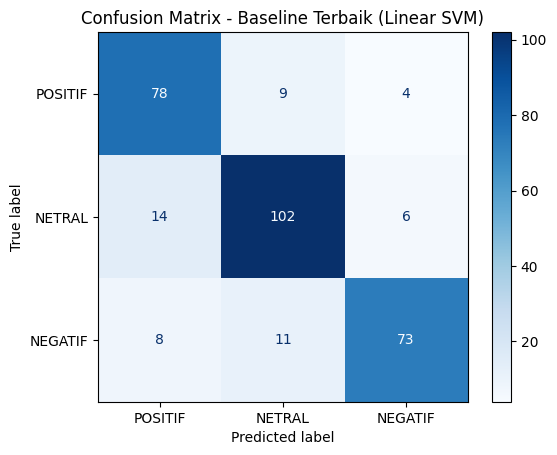

In [ ]:
labels_order = ['POSITIF', 'NETRAL', 'NEGATIF']
cm = confusion_matrix(y_valid, best_valid_pred, labels=labels_order)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(cmap='Blues', values_format='d')
plt.title(f'Confusion Matrix - Baseline Terbaik ({BEST_MODEL_NAME})')
plt.show()

Confusion matrix menunjukkan bahwa model Linear SVM berhasil memprediksi dengan benar 78 data POSITIF, 102 data NETRAL, dan 73 data NEGATIF. Kesalahan paling banyak terjadi ketika data NETRAL diprediksi sebagai POSITIF (14 data). Model juga beberapa kali tertukar antara NEGATIF dan NETRAL. Secara keseluruhan, model mampu mengenali ketiga kelas dengan cukup baik, tetapi masih mengalami kesulitan membedakan sentimen yang konteksnya berdekatan.

### Pretrained Model (IndoBERT — Fine-tuning & Hyperparameter Tuning)

Baseline klasik di atas tetap menjadi acuan pembanding. Selanjutnya kita fine-tune **IndoBERT** (`indobert-base-p1`) pada **split stratified 80:20 yang sama** (`X_train`/`X_valid`).

Strategi tuning dibuat bertahap supaya konfigurasi buruk cepat tersaring:

1. **Tahap 1** — saring `learning_rate` (1e-5, 2e-5, 3e-5) × `epochs` (2-4) pada konfigurasi dasar (`max_len=128`, `batch_size=16`, `weight_decay=0.01`, `warmup_ratio=0.1`, tanpa class weighting).
2. **Tahap 2** — dari konfigurasi terbaik Tahap 1, uji faktor spesifik lain: `max_len`, class weighting, `batch_size`, `weight_decay`/`warmup_ratio`, dan epoch tambahan.

**Data augmentation** dan **5-fold CV** sengaja tidak dijadikan default: kalimat pendek pada dataset ini rentan berubah makna jika kata diganti/dihapus, dan fine-tuning model 124.5M parameter dengan CV penuh akan melipatgandakan biaya training tanpa informasi tambahan yang sebanding.

In [ ]:
RUN_INDOBERT = True
INDOBERT_MODEL_P1 = 'indobenchmark/indobert-base-p1'

INDOBERT_SEED = RANDOM_STATE
INDOBERT_PATIENCE = 1

DEFAULT_BATCH_CUDA = 16
DEFAULT_BATCH_CPU = 4

In [ ]:
LABEL2ID = {'NEGATIF': 0, 'NETRAL': 1, 'POSITIF': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    if INDOBERT_AVAILABLE:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

if INDOBERT_AVAILABLE:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print('Device:', device)

class FastIndoBERTDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(list(texts), truncation=True, padding='max_length', max_length=max_len,)
        self.labels = None if labels is None else [LABEL2ID[x] for x in labels]

    def __len__(self):
        return len(self.encodings['input_ids'])

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx], dtype=torch.long) for k, v in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

def make_model(model_name):
    config = AutoConfig.from_pretrained(model_name)
    config.num_labels = 3
    config.id2label = ID2LABEL
    config.label2id = LABEL2ID
    return AutoModelForSequenceClassification.from_pretrained(model_name, config=config, ignore_mismatched_sizes=True,).to(device)

def make_class_weights(y):
    counts = pd.Series(y).value_counts()
    total = len(y)
    n_classes = 3
    weights = [total / (n_classes * counts[label]) for label in ['NEGATIF', 'NETRAL', 'POSITIF']]
    return torch.tensor(weights, dtype=torch.float, device=device)

def softmax(scores):
    scores = scores - np.max(scores, axis=1, keepdims=True)
    exp_scores = np.exp(scores)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

tokenizer_cache = {}

Device: cuda


In [ ]:
def train_one_config(config, model_name=INDOBERT_MODEL_P1, verbose=True, return_details=False):
    seed_everything(INDOBERT_SEED)

    max_len = int(config['max_len'])
    batch_size = int(config['batch_size'])
    epochs = int(config['epochs'])
    lr = float(config['learning_rate'])
    wd = float(config['weight_decay'])
    warmup_ratio = float(config['warmup_ratio'])
    use_class_weight = bool(config['class_weight'])

    tokenizer = tokenizer_cache.setdefault((model_name, max_len), AutoTokenizer.from_pretrained(model_name))
    train_ds = FastIndoBERTDataset(X_train, y_train, tokenizer, max_len)
    valid_ds = FastIndoBERTDataset(X_valid, y_valid, tokenizer, max_len)

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, num_workers=0,
        pin_memory=(device.type == 'cuda')
    )
    valid_loader = DataLoader(
        valid_ds, batch_size=batch_size, shuffle=False, num_workers=0,
        pin_memory=(device.type == 'cuda')
    )

    model = make_model(model_name)
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=wd)

    total_steps = epochs * len(train_loader)
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps,
    )

    criterion = None
    if use_class_weight:
        criterion = torch.nn.CrossEntropyLoss(weight=make_class_weights(y_train))

    best_f1 = -1.0
    best_epoch = 0
    best_details = None
    no_improve = 0

    for epoch in range(1, epochs + 1):
        model.train()
        train_true, train_pred = [], []
        train_loss = 0.0

        for batch in train_loader:
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            labels = batch.pop('labels')
            optimizer.zero_grad(set_to_none=True)

            outputs = model(**batch)
            loss = criterion(outputs.logits, labels) if criterion is not None else torch.nn.functional.cross_entropy(outputs.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            train_pred.extend(outputs.logits.argmax(dim=1).detach().cpu().tolist())
            train_true.extend(labels.detach().cpu().tolist())

        train_f1 = f1_score(train_true, train_pred, average='macro')

        model.eval()
        val_true, val_pred, val_probs = [], [], []
        val_loss = 0.0
        with torch.no_grad():
            for batch in valid_loader:
                batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
                labels = batch.pop('labels')
                outputs = model(**batch)
                loss = criterion(outputs.logits, labels) if criterion is not None else torch.nn.functional.cross_entropy(outputs.logits, labels)
                val_loss += loss.item()
                val_probs.append(torch.softmax(outputs.logits, dim=1).cpu().numpy())
                val_pred.extend(outputs.logits.argmax(dim=1).cpu().tolist())
                val_true.extend(labels.cpu().tolist())

        val_probs = np.concatenate(val_probs, axis=0)
        val_f1 = f1_score(val_true, val_pred, average='macro')

        if verbose:
            print(
                f"  epoch {epoch}/{epochs} | "
                f"train_loss={train_loss/len(train_loader):.4f} | "
                f"val_loss={val_loss/len(valid_loader):.4f} | "
                f"train_f1={train_f1:.4f} | val_f1={val_f1:.4f}"
            )

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_epoch = epoch
            no_improve = 0
            if return_details:
                best_details = {
                    'y_true': np.array(val_true),
                    'y_pred': np.array(val_pred),
                    'y_probs': val_probs,
                }
        else:
            no_improve += 1
            if no_improve >= INDOBERT_PATIENCE:
                break

    del model, optimizer, scheduler, train_loader, valid_loader, train_ds, valid_ds
    if device.type == 'cuda':
        torch.cuda.empty_cache()

    if return_details:
        return best_f1, best_epoch, best_details
    return best_f1, best_epoch

#### Step 1: Filter learning rate + epoch

Dimulai dari konfigurasi yang paling menentukan: learning rate dan epoch. Max length 128, batch size 16, `weight_decay=0.01`, warmup 10%, dan tanpa class weighting dijadikan titik awal.

In [ ]:
if RUN_INDOBERT and INDOBERT_AVAILABLE:
    stage1_configs = []
    for lr in [1e-5, 2e-5, 3e-5]:
        for ep in [2, 3, 4]:
            stage1_configs.append({
                'learning_rate': lr,
                'epochs': ep,
                'max_len': 128,
                'batch_size': DEFAULT_BATCH_CUDA if device.type == 'cuda' else DEFAULT_BATCH_CPU,
                'weight_decay': 0.01,
                'warmup_ratio': 0.10,
                'class_weight': False,
            })

    stage1_results = []
    print('STAGE 1 — learning rate × epoch')
    print('=' * 70)

    for i, cfg in enumerate(stage1_configs, 1):
        print(
            f"\n[{i}/{len(stage1_configs)}] "
            f"lr={cfg['learning_rate']:.0e} | epochs={cfg['epochs']} | max_len=128"
        )
        f1, best_epoch = train_one_config(cfg, INDOBERT_MODEL_P1, verbose=True)
        row = dict(cfg)
        row['model'] = 'IndoBERT-base-p1'
        row['best_epoch'] = best_epoch
        row['val_macro_f1'] = f1
        row['stage'] = 'stage1'
        stage1_results.append(row)

    stage1_df = pd.DataFrame(stage1_results).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
    display(stage1_df)
    best_stage1 = stage1_df.iloc[0].to_dict()
    print(f"\nBest Stage 1: F1={best_stage1['val_macro_f1']:.4f} | lr={best_stage1['learning_rate']:.0e} | epochs={int(best_stage1['epochs'])}")
else:
    stage1_df = pd.DataFrame()
    best_stage1 = None

STAGE 1 — learning rate × epoch

[1/9] lr=1e-05 | epochs=2 | max_len=128


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/2 | train_loss=0.7813 | val_loss=0.5324 | train_f1=0.6580 | val_f1=0.8230
  epoch 2/2 | train_loss=0.5042 | val_loss=0.4955 | train_f1=0.8149 | val_f1=0.8504

[2/9] lr=1e-05 | epochs=3 | max_len=128


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/4 | train_loss=0.7422 | val_loss=0.6134 | train_f1=0.6864 | val_f1=0.7957
  epoch 2/4 | train_loss=0.4034 | val_loss=0.4595 | train_f1=0.8448 | val_f1=0.8528
  epoch 3/4 | train_loss=0.1794 | val_loss=0.5805 | train_f1=0.9366 | val_f1=0.8435


,learning_rate,epochs,max_len,batch_size,weight_decay,warmup_ratio,class_weight,model,best_epoch,val_macro_f1,stage
0,0.00002,2,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.853997,stage1
1,0.00002,3,128,16,0.01,0.1,False,IndoBERT-base-p1,3,0.853402,stage1
2,0.00003,4,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.852806,stage1
3,0.00001,2,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.850413,stage1
4,0.00003,2,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.850023,stage1
5,0.00003,3,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.849708,stage1
6,0.00002,4,128,16,0.01,0.1,False,IndoBERT-base-p1,3,0.847289,stage1
7,0.00001,4,128,16,0.01,0.1,False,IndoBERT-base-p1,3,0.846880,stage1
8,0.00001,3,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.844294,stage1



Best Stage 1: F1=0.8540 | lr=2e-05 | epochs=2


Pada Tahap 1, sembilan kombinasi learning rate dan epoch diuji dengan konfigurasi dasar yang sama. Hasil terbaik diperoleh pada **learning rate `2e-5` dan 2 epoch**, dengan validation Macro F1 sebesar **0,8540**. Konfigurasi ini menjadi titik awal untuk Tahap 2, yaitu pengujian parameter lainnya. Pada beberapa konfigurasi, skor validation tidak meningkat ketika epoch ditambah, sehingga jumlah epoch yang lebih banyak belum tentu menghasilkan performa yang lebih baik.


#### Step 2: Test more specific factors

Setelah learning rate/epoch tersaring, uji hal yang paling mungkin mengubah performa tanpa melakukan full grid yang sangat mahal: panjang token, class weighting, batch size, regularisasi, dan warmup.

In [ ]:
if RUN_INDOBERT and INDOBERT_AVAILABLE and best_stage1 is not None:
    base_bs = DEFAULT_BATCH_CUDA if device.type == 'cuda' else DEFAULT_BATCH_CPU

    stage2_configs = [
        {**best_stage1, 'max_len': 96, 'batch_size': base_bs},
        {**best_stage1, 'max_len': 160, 'batch_size': base_bs},
        {**best_stage1, 'class_weight': True, 'batch_size': base_bs},
        {**best_stage1, 'batch_size': max(4, base_bs // 2)},
        {**best_stage1, 'weight_decay': 0.0, 'warmup_ratio': 0.0, 'batch_size': base_bs},
        {**best_stage1, 'weight_decay': 0.01, 'warmup_ratio': 0.0, 'batch_size': base_bs},
        {**best_stage1, 'epochs': 5, 'batch_size': base_bs},
        {**best_stage1, 'learning_rate': 1e-5, 'epochs': 5, 'batch_size': base_bs},
    ]

    unique = []
    seen = set()
    for cfg in stage2_configs:
        key = tuple(sorted((k, str(v)) for k, v in cfg.items() if k not in ['model', 'stage', 'best_epoch', 'val_macro_f1']))
        if key not in seen:
            unique.append(cfg)
            seen.add(key)

    stage2_results = []
    print('STAGE 2 — focused tuning')
    print('=' * 70)

    for i, cfg in enumerate(unique, 1):
        print(
            f"\n[{i}/{len(unique)}] "
            f"lr={cfg['learning_rate']:.0e} | ep={cfg['epochs']} | "
            f"len={cfg['max_len']} | bs={cfg['batch_size']} | "
            f"wd={cfg['weight_decay']} | warmup={cfg['warmup_ratio']} | "
            f"class_weight={cfg['class_weight']}"
        )
        f1, best_epoch = train_one_config(cfg, INDOBERT_MODEL_P1, verbose=True)
        row = dict(cfg)
        row['model'] = 'IndoBERT-base-p1'
        row['best_epoch'] = best_epoch
        row['val_macro_f1'] = f1
        row['stage'] = 'stage2'
        stage2_results.append(row)

    stage2_df = pd.DataFrame(stage2_results).sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
    display(stage2_df)

    all_tuning_results = pd.concat([stage1_df, stage2_df], ignore_index=True)
    all_tuning_results = all_tuning_results.sort_values('val_macro_f1', ascending=False).reset_index(drop=True)
    best_overall = all_tuning_results.iloc[0].to_dict()

    print('\nBEST INDOBERT CONFIG:')
    print(pd.Series(best_overall))
else:
    stage2_df = pd.DataFrame()
    all_tuning_results = pd.DataFrame()
    best_overall = None

STAGE 2 — focused tuning

[1/8] lr=2e-05 | ep=2 | len=96 | bs=16 | wd=0.01 | warmup=0.1 | class_weight=False


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/2 | train_loss=0.7059 | val_loss=0.5875 | train_f1=0.7071 | val_f1=0.7939
  epoch 2/2 | train_loss=0.4114 | val_loss=0.4651 | train_f1=0.8435 | val_f1=0.8462

[2/8] lr=2e-05 | ep=2 | len=160 | bs=16 | wd=0.01 | warmup=0.1 | class_weight=False


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/5 | train_loss=0.8362 | val_loss=0.5649 | train_f1=0.6215 | val_f1=0.8053
  epoch 2/5 | train_loss=0.4979 | val_loss=0.4701 | train_f1=0.8153 | val_f1=0.8374
  epoch 3/5 | train_loss=0.3415 | val_loss=0.4947 | train_f1=0.8688 | val_f1=0.8465
  epoch 4/5 | train_loss=0.2447 | val_loss=0.5059 | train_f1=0.9141 | val_f1=0.8340


,learning_rate,epochs,max_len,batch_size,weight_decay,warmup_ratio,class_weight,model,best_epoch,val_macro_f1,stage
0,0.00002,2,160,16,0.01,0.1,False,IndoBERT-base-p1,2,0.853269,stage2
1,0.00002,2,128,16,0.01,0.1,True,IndoBERT-base-p1,2,0.850991,stage2
2,0.00002,5,128,16,0.01,0.1,False,IndoBERT-base-p1,3,0.847411,stage2
3,0.00001,5,128,16,0.01,0.1,False,IndoBERT-base-p1,3,0.846549,stage2
4,0.00002,2,96,16,0.01,0.1,False,IndoBERT-base-p1,2,0.846170,stage2
5,0.00002,2,128,8,0.01,0.1,False,IndoBERT-base-p1,2,0.844483,stage2
6,0.00002,2,128,16,0.01,0.0,False,IndoBERT-base-p1,2,0.843905,stage2
7,0.00002,2,128,16,0.00,0.0,False,IndoBERT-base-p1,2,0.843905,stage2



BEST INDOBERT CONFIG:
learning_rate             0.00002
epochs                          2
max_len                       128
batch_size                     16
weight_decay                 0.01
warmup_ratio                  0.1
class_weight                False
model            IndoBERT-base-p1
best_epoch                      2
val_macro_f1             0.853997
stage                      stage1
dtype: object


Pada Tahap 2, dilakukan pengujian terhadap beberapa faktor spesifik berdasarkan konfigurasi terbaik Tahap 1. Hasil terbaik diperoleh pada **`max_len=160`** dengan validation Macro F1 sebesar **0,8533**, namun masih sedikit di bawah hasil terbaik Tahap 1 sebesar **0,8540**. Penggunaan `class_weight=True` juga belum meningkatkan performa, dengan skor **0,8510**. Pengurangan batch size menjadi 8 menghasilkan **0,8445**, sedangkan perubahan weight decay dan warmup menghasilkan **0,8439**. Penambahan epoch hingga 5 juga tidak memberikan peningkatan yang berarti. Dengan demikian, **konfigurasi Tahap 1 (`lr=2e-5`, 2 epoch, `max_len=128`) tetap menjadi konfigurasi terbaik berdasarkan hasil tuning yang tersedia.**

#### Tuning Summary

`best_tuning_results.csv` menyimpan seluruh percobaan Tahap 1 + Tahap 2 supaya pilihan hyperparameter dapat diaudit berdasarkan **Validation Macro F1**.

In [ ]:
if RUN_INDOBERT and INDOBERT_AVAILABLE and not all_tuning_results.empty:
    all_tuning_results.to_csv('best_tuning_results.csv', index=False)
    display(all_tuning_results.head(15))
    print('Saved: best_tuning_results.csv')

,learning_rate,epochs,max_len,batch_size,weight_decay,warmup_ratio,class_weight,model,best_epoch,val_macro_f1,stage
0,0.00002,2,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.853997,stage1
1,0.00002,3,128,16,0.01,0.1,False,IndoBERT-base-p1,3,0.853402,stage1
2,0.00002,2,160,16,0.01,0.1,False,IndoBERT-base-p1,2,0.853269,stage2
3,0.00003,4,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.852806,stage1
4,0.00002,2,128,16,0.01,0.1,True,IndoBERT-base-p1,2,0.850991,stage2
5,0.00001,2,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.850413,stage1
6,0.00003,2,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.850023,stage1
7,0.00003,3,128,16,0.01,0.1,False,IndoBERT-base-p1,2,0.849708,stage1
8,0.00002,5,128,16,0.01,0.1,False,IndoBERT-base-p1,3,0.847411,stage2
9,0.00002,4,128,16,0.01,0.1,False,IndoBERT-base-p1,3,0.847289,stage1


Saved: best_tuning_results.csv


#### Best IndoBERT Evaluation on Validation

Konfigurasi pemenang (`best_overall`) dilatih ulang **hanya di `X_train`** lewat `train_one_config(..., return_details=True)`

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 1/2 | train_loss=0.7209 | val_loss=0.5330 | train_f1=0.7037 | val_f1=0.8194
  epoch 2/2 | train_loss=0.4144 | val_loss=0.4643 | train_f1=0.8370 | val_f1=0.8540

IndoBERT Validation Macro F1 (best epoch=2): 0.8540


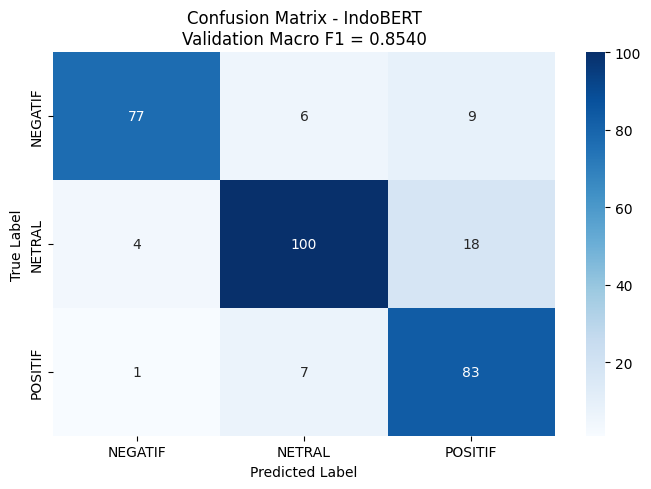


Classification Report:

              precision    recall  f1-score   support

     NEGATIF     0.9390    0.8370    0.8851        92
      NETRAL     0.8850    0.8197    0.8511       122
     POSITIF     0.7545    0.9121    0.8259        91

    accuracy                         0.8525       305
   macro avg     0.8595    0.8562    0.8540       305
weighted avg     0.8624    0.8525    0.8538       305



In [ ]:
if RUN_INDOBERT and INDOBERT_AVAILABLE and best_overall is not None:
    indobert_val_f1, indobert_val_epoch, indobert_val_details = train_one_config(
        best_overall, INDOBERT_MODEL_P1, verbose=True, return_details=True
    )

    indobert_valid_true = indobert_val_details['y_true']
    indobert_valid_pred = indobert_val_details['y_pred']
    indobert_valid_probs = indobert_val_details['y_probs']

    print(f"\nIndoBERT Validation Macro F1 (best epoch={indobert_val_epoch}): {indobert_val_f1:.4f}")

    label_names = [ID2LABEL[i] for i in range(3)]
    cm = confusion_matrix(indobert_valid_true, indobert_valid_pred, labels=[0, 1, 2])

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - IndoBERT\nValidation Macro F1 = {indobert_val_f1:.4f}')
    plt.tight_layout()
    plt.show()

    print("\nClassification Report:\n")
    print(classification_report(indobert_valid_true, indobert_valid_pred, target_names=label_names, digits=4))
else:
    indobert_val_f1 = None
    indobert_valid_probs = None
    print('Evaluasi dilewati karena IndoBERT belum dijalankan.')

Konfigurasi terbaik IndoBERT dilatih ulang menggunakan data training dan dievaluasi pada validation set. Hasilnya menunjukkan Macro F1 sebesar 0,8540 dengan performa yang cukup seimbang pada ketiga kelas. Kelas NEGATIF memperoleh F1-score tertinggi sebesar 0,8851, diikuti NETRAL sebesar 0,8511 dan POSITIF sebesar 0,8259. Model mencapai accuracy 85,25%. Confusion matrix menunjukkan bahwa sebagian besar data berhasil diklasifikasikan dengan benar, meskipun masih terdapat kesalahan terutama antara kelas NETRAL dan NEGATIF. Secara keseluruhan, konfigurasi terbaik IndoBERT memberikan performa yang lebih baik dan relatif seimbang dalam mengklasifikasikan ketiga sentimen.

#### Final IndoBERT (Retrain on All Labeled Data)

Hyperparameter dipilih menggunakan validation 20% di atas. Setelah konfigurasi terbaik didapat, model dilatih ulang pada **seluruh `train_dedup` (100% data berlabel)** memakai jumlah epoch dari epoch terbaik hasil tuning.

In [ ]:
if RUN_INDOBERT and INDOBERT_AVAILABLE and best_overall is not None:
    seed_everything(INDOBERT_SEED)

    final_lr = float(best_overall['learning_rate'])
    final_epochs = int(best_overall.get('best_epoch') or best_overall['epochs'])
    final_max_len = int(best_overall['max_len'])
    final_batch_size = int(best_overall['batch_size'])
    final_wd = float(best_overall['weight_decay'])
    final_warmup_ratio = float(best_overall['warmup_ratio'])
    final_class_weight = bool(best_overall['class_weight'])

    final_tokenizer = AutoTokenizer.from_pretrained(INDOBERT_MODEL_P1)
    final_train_ds = FastIndoBERTDataset(X, y, final_tokenizer, final_max_len)
    final_train_loader = DataLoader(
        final_train_ds, batch_size=final_batch_size, shuffle=True, num_workers=0,
        pin_memory=(device.type == 'cuda'),
    )

    final_model = make_model(INDOBERT_MODEL_P1)
    final_optimizer = AdamW(final_model.parameters(), lr=final_lr, weight_decay=final_wd)
    final_total_steps = final_epochs * len(final_train_loader)
    final_warmup_steps = int(final_total_steps * final_warmup_ratio)
    final_scheduler = get_linear_schedule_with_warmup(
        final_optimizer, num_warmup_steps=final_warmup_steps, num_training_steps=final_total_steps,
    )
    final_criterion = torch.nn.CrossEntropyLoss(weight=make_class_weights(y)) if final_class_weight else None

    print('FINAL TRAINING')
    print('Model        : IndoBERT-base-p1')
    print(f'Samples      : {len(final_train_ds)}')
    print(f'Epochs       : {final_epochs}')
    print(f'LR           : {final_lr}')
    print(f'Max length   : {final_max_len}')
    print(f'Batch size   : {final_batch_size}')
    print(f'Weight decay : {final_wd}')
    print(f'Warmup ratio : {final_warmup_ratio}')
    print(f'Class weight : {final_class_weight}')

    for epoch in range(1, final_epochs + 1):
        final_model.train()
        total_loss = 0.0
        preds, true = [], []

        for batch in final_train_loader:
            batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
            labels = batch.pop('labels')
            final_optimizer.zero_grad(set_to_none=True)
            outputs = final_model(**batch)
            loss = final_criterion(outputs.logits, labels) if final_criterion is not None else torch.nn.functional.cross_entropy(outputs.logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)
            final_optimizer.step()
            final_scheduler.step()
            total_loss += loss.item()
            preds.extend(outputs.logits.argmax(dim=1).detach().cpu().tolist())
            true.extend(labels.detach().cpu().tolist())

        train_f1_full = f1_score(true, preds, average='macro')
        print(f'Epoch {epoch}/{final_epochs} | Train Loss={total_loss/len(final_train_loader):.4f} | Train Macro F1={train_f1_full:.4f}')
else:
    final_model = None
    final_tokenizer = None
    print('Final IndoBERT dilewati karena dependency/model belum tersedia.')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


FINAL TRAINING
Model        : IndoBERT-base-p1
Samples      : 1524
Epochs       : 2
LR           : 2e-05
Max length   : 128
Batch size   : 16
Weight decay : 0.01
Warmup ratio : 0.1
Class weight : False
Epoch 1/2 | Train Loss=0.6737 | Train Macro F1=0.7318
Epoch 2/2 | Train Loss=0.3838 | Train Macro F1=0.8511


Setelah hyperparameter terbaik ditentukan melalui validation set, IndoBERT dilatih ulang menggunakan seluruh 1.524 data berlabel dengan konfigurasi terbaik, yaitu learning rate 2e-5, 2 epoch, max_len=128, batch size 16, weight decay 0.01, warmup ratio 0.1, dan tanpa class weighting. Pada epoch pertama, Train Macro F1 sebesar 0,7318, kemudian meningkat menjadi 0,8511 pada epoch kedua dengan Train Loss turun dari 0,6737 menjadi 0,3838. Hal ini menunjukkan bahwa model berhasil mempelajari pola sentimen dari seluruh data training. Model final ini selanjutnya digunakan untuk melakukan prediksi pada data test.

### Final Ensemble (IndoBERT and LinearSVM)

Final model dibuat dari **ensemble IndoBERT + Linear SVM**: probabilitas IndoBERT (`indobert_valid_probs`, dari bagian Evaluasi di atas) digabung dengan probabilitas Linear SVM pada validation set untuk mencari bobot terbaik, lalu kedua model dilatih ulang pada 100% data sebelum dipakai memprediksi test set.

Linear SVM di sini memakai ulang nilai `C` terbaik yang sudah ditemukan di perbandingan 5 baseline model.

In [ ]:
svm_rows = validation_results_df[validation_results_df['model'] == 'Linear SVM'].reset_index(drop=True)
best_svm_key = svm_rows.loc[0, 'key']
best_svm_C = float(validation_params[best_svm_key]['C'])
best_valid_svm = validation_models[best_svm_key]  # sudah di-fit pada X_train
print(f"Linear SVM terpilih: C={best_svm_C} (Holdout Macro F1={svm_rows.loc[0, 'macro_f1']:.4f})")

Linear SVM terpilih: C=0.25 (Holdout Macro F1=0.8290)


In [ ]:
y_valid_ids = np.array([LABEL2ID[label] for label in y_valid])

svm_decision_valid = best_valid_svm.decision_function(X_valid)
svm_classes = list(best_valid_svm.named_steps['clf'].classes_)
svm_valid_scores = np.zeros((len(X_valid), 3))
for i, cls in enumerate(svm_classes):
  svm_valid_scores[:, LABEL2ID[str(cls).upper()]] = svm_decision_valid[:, i]
svm_valid_probs = softmax(svm_valid_scores)

svm_valid_pred = np.argmax(svm_valid_probs, axis=1)
svm_valid_f1 = f1_score(y_valid_ids, svm_valid_pred, average='macro')
print(f"Linear SVM  Validation Macro F1 : {svm_valid_f1:.4f}")
print(f"IndoBERT    Validation Macro F1 : {indobert_val_f1:.4f}")

Linear SVM  Validation Macro F1 : 0.8290
IndoBERT    Validation Macro F1 : 0.8540


Pada tahap ensemble, IndoBERT dan Linear SVM dibandingkan berdasarkan performanya pada validation set sebelum digabungkan. IndoBERT memperoleh **Validation Macro F1 sebesar 0,8540**, sedangkan Linear SVM memperoleh **0,8290**. Hasil ini menunjukkan bahwa kedua model memiliki kemampuan klasifikasi yang baik, dengan IndoBERT memberikan performa validation yang lebih tinggi. Selanjutnya, probabilitas prediksi dari kedua model digunakan untuk mencari kombinasi bobot ensemble terbaik. Setelah bobot ditentukan, kedua model dilatih ulang menggunakan **100% data berlabel** dan hasil ensemble digunakan untuk melakukan prediksi pada data test.


#### Find the best ensemble weights on the validation set

In [ ]:
ensemble_results = []
for w_indobert in np.arange(0.0, 1.001, 0.05):
  w_svm = 1.0 - w_indobert
  combined_probs = w_indobert * indobert_valid_probs + w_svm * svm_valid_probs
  combined_pred = np.argmax(combined_probs, axis=1)
  combined_f1 = f1_score(y_valid_ids, combined_pred, average='macro')
  ensemble_results.append({
      'IndoBERT_weight': w_indobert, 'SVM_weight': w_svm,
      'macro_f1': combined_f1, 'improvement_vs_IndoBERT': combined_f1 - indobert_val_f1,})
  ensemble_results_df = (pd.DataFrame(ensemble_results).sort_values('macro_f1', ascending=False).reset_index(drop=True))
  print("\nKomposisi ensemble (top 5):")
  display(ensemble_results_df.head(5))

  best_ensemble_row = ensemble_results_df.iloc[0]
  best_indobert_weight = float(best_ensemble_row['IndoBERT_weight'])
  best_svm_weight = float(best_ensemble_row['SVM_weight'])
  best_ensemble_f1 = float(best_ensemble_row['macro_f1'])

  print(f"\nENSEMBLE TERBAIK: IndoBERT={best_indobert_weight:.2f} | SVM={best_svm_weight:.2f}")
  print(f"Validation Macro F1: {best_ensemble_f1:.4f} ({best_ensemble_f1 - indobert_val_f1:+.4f} vs IndoBERT)")



Komposisi ensemble (top 5):


,IndoBERT_weight,SVM_weight,macro_f1,improvement_vs_IndoBERT
0,0.0,1.0,0.829035,-0.024962



ENSEMBLE TERBAIK: IndoBERT=0.00 | SVM=1.00
Validation Macro F1: 0.8290 (-0.0250 vs IndoBERT)

Komposisi ensemble (top 5):


,IndoBERT_weight,SVM_weight,macro_f1,improvement_vs_IndoBERT
0,0.05,0.95,0.829215,-0.024782
1,0.00,1.00,0.829035,-0.024962



ENSEMBLE TERBAIK: IndoBERT=0.05 | SVM=0.95
Validation Macro F1: 0.8292 (-0.0248 vs IndoBERT)

Komposisi ensemble (top 5):


...


ENSEMBLE TERBAIK: IndoBERT=0.60 | SVM=0.40
Validation Macro F1: 0.8540 (+0.0000 vs IndoBERT)

Komposisi ensemble (top 5):


,IndoBERT_weight,SVM_weight,macro_f1,improvement_vs_IndoBERT
0,0.60,0.40,0.853997,0.000000
1,0.90,0.10,0.850675,-0.003322
2,0.95,0.05,0.850675,-0.003322
3,0.85,0.15,0.850675,-0.003322
4,0.75,0.25,0.850675,-0.003322



ENSEMBLE TERBAIK: IndoBERT=0.60 | SVM=0.40
Validation Macro F1: 0.8540 (+0.0000 vs IndoBERT)

Komposisi ensemble (top 5):


,IndoBERT_weight,SVM_weight,macro_f1,improvement_vs_IndoBERT
0,0.60,0.40,0.853997,0.000000
1,1.00,0.00,0.853997,0.000000
2,0.85,0.15,0.850675,-0.003322
3,0.90,0.10,0.850675,-0.003322
4,0.70,0.30,0.850675,-0.003322



ENSEMBLE TERBAIK: IndoBERT=0.60 | SVM=0.40
Validation Macro F1: 0.8540 (+0.0000 vs IndoBERT)


Ensemble menggabungkan Linear SVM berbasis TF-IDF yang menangkap pola kata/frasa dengan IndoBERT yang mempertimbangkan konteks kalimat. Dari berbagai kombinasi bobot, hasil terbaik diperoleh pada **60% IndoBERT dan 40% Linear SVM** dengan Validation Macro F1 **0,8540**, sama dengan IndoBERT secara individual. Meskipun belum meningkatkan skor validation, kombinasi ini tetap digunakan pada tahap final karena menggabungkan dua pendekatan yang berbeda dan berpotensi saling melengkapi pada data test.


#### Retrain the SVM on 100% of the data
(the IndoBERT `final_model` is already based on 100% of the data).

In [ ]:
final_svm = make_baseline_pipeline('svm', C=best_svm_C)
final_svm.fit(X, y)
print(f"\nSVM final dilatih ulang pada {len(X)} sampel (100% data).")


SVM final dilatih ulang pada 1524 sampel (100% data).


#### Test Set Prediction

In [ ]:
test_ds = FastIndoBERTDataset(test['kalimat'].astype(str), None, final_tokenizer, final_max_len)
test_loader = DataLoader(
    test_ds, batch_size=final_batch_size, shuffle=False, num_workers=0,
    pin_memory=(device.type == 'cuda'),)
final_model.eval()
indobert_test_probs_list = []
with torch.no_grad():
  for batch in test_loader:
    batch = {k: v.to(device, non_blocking=True) for k, v in batch.items()}
    logits = final_model(**batch).logits
    indobert_test_probs_list.append(torch.softmax(logits, dim=1).cpu().numpy())
indobert_test_probs = np.concatenate(indobert_test_probs_list, axis=0)

svm_test_decision = final_svm.decision_function(test['kalimat'].astype(str))
svm_test_classes = list(final_svm.named_steps['clf'].classes_)
svm_test_scores = np.zeros((len(test), 3))
for i, cls in enumerate(svm_test_classes):
  svm_test_scores[:, LABEL2ID[str(cls).upper()]] = svm_test_decision[:, i]
svm_test_probs = softmax(svm_test_scores)

final_ensemble_probs = best_indobert_weight * indobert_test_probs + best_svm_weight * svm_test_probs
final_pred_ids = np.argmax(final_ensemble_probs, axis=1)
final_pred_labels = [ID2LABEL[i] for i in final_pred_ids]

## Submission

In [ ]:
submission_ensemble = pd.DataFrame({'id': test['id'], 'sentiment_label': final_pred_labels})
submission_ensemble.to_csv('submission.csv', index=False)

print("Saved: submission.csv")
print("\nDistribusi prediksi:")
print(submission_ensemble['sentiment_label'].value_counts())

Saved: submission.csv

Distribusi prediksi:
sentiment_label
NETRAL     252
POSITIF    211
NEGATIF    191
Name: count, dtype: int64


Model final digunakan untuk memprediksi 654 data pada test set. Prediksi dilakukan menggunakan ensemble 60% IndoBERT dan 40% Linear SVM, kemudian kelas dengan skor ensemble tertinggi dipilih sebagai label akhir. Hasil prediksi menunjukkan distribusi sebanyak 252 NETRAL (38,5%), 211 POSITIF (32,3%), dan 191 NEGATIF (29,2%).

## Insight

1. Insight EDA paling penting: unigram tidak cukup, tapi bigram/trigram sangat informatif.
Karena semua kelas berpusat pada topik yang sama (berita BRI), kata tunggal seperti "bri", "rp", "di" muncul merata di ketiga kelas — tidak ada sinyal sentimen. Baru di level frasa 2-3 kata pola jadi jelas: POSITIF = "meraih/mencetak/menyalurkan" (prestasi & CSR), NETRAL = bahasa laporan pasar faktual ("ditutup menguat", "rekomendasi saham"), NEGATIF = "perampokan/dana nasabah/keluhan". Ini alasan konkret kenapa ngram_range=(1,2) di TF-IDF bukan pilihan sembarangan, itu keputusan yang didukung EDA, dan juga menjelaskan kenapa IndoBERT (yang membaca konteks penuh) unggul jauh dari model bag-of-words.

2. Temuan kunci di run ini: gain IndoBERT ke SVM konsisten (+2.5pp), tapi gain ensemble ke IndoBERT = 0.
Bobot optimal ternyata 60:40 tapi skornya identik dengan IndoBERT sendirian (0.8540 = 0.8540). Ini insight penting: manfaat ensembling di dataset ini rapuh dan sangat tergantung random seed/split, bukan peningkatan yang solid dan reproducible. Dengan validation cuma 305 sampel, perbedaan 1 baris prediksi saja bisa mengubah kesimpulan "ensemble menang" jadi "ensemble seri".

3. IndoBERT tetap kontributor performa dominan, sekali lagi terkonfirmasi.
Lompatan dari baseline (0.829) ke IndoBERT (0.854) adalah +2.5pp, jauh lebih besar dari potensi gain ensembling. Pola ini konsisten di kedua run yang sudah kita coba: representasi kontekstual BERT lebih berharga daripada teknik ensembling di atas model yang lebih lemah.

4. Precision/recall IndoBERT menunjukkan bias yang jelas: model "terlalu mudah" memprediksi POSITIF.
Recall POSITIF tinggi (0.9121) tapi precision-nya paling rendah (0.7545) artinya model sering salah menandai kalimat NETRAL/NEGATIF sebagai POSITIF. Sebaliknya NEGATIF punya precision tertinggi (0.9390) tapi recall lebih rendah (0.8370), model konservatif dalam memprediksi NEGATIF, cenderung melewatkannya. Pola confusion ini konsisten dengan baseline SVM (paling sering keliru antara NETRAL↔POSITIF), mengonfirmasi lagi bahwa batas NETRAL-POSITIF adalah "zona abu-abu" struktural dari data, bukan kelemahan model tertentu.

5. Distribusi prediksi akhir sangat mendekati distribusi label training (38,5% NETRAL vs 40% di train; 32,3% POSITIF vs 30%; 29,2% NEGATIF vs 30%), sinyal bagus bahwa model tidak bias parah ke satu kelas dan generalisasinya wajar, tidak overfit ke satu label dominan.